# Plankton Community Time Series (2019–2024)
Daily density measurements (counts µL⁻¹) from a lake monitoring programme.
The heatmap shows all 82 taxa simultaneously, with species sorted by their seasonal peak month.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Load & clean ──────────────────────────────────────────────────────────────
df = pd.read_csv('TimeSeries_countsuL_clean.csv', index_col=0, parse_dates=True)
df.index.name = 'date'

# Drop rows that are completely empty (first 5 dates have no observations)
df = df.dropna(how='all')

# Fill remaining NaNs with 0 (missing counts = not detected)
df = df.fillna(0)

print(f'Date range : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Taxa       : {df.shape[1]}')
print(f'Daily obs  : {df.shape[0]}')

Date range : 2019-03-26 → 2024-12-31
Taxa       : 83
Daily obs  : 2066


In [3]:
# ── Monthly resampling ────────────────────────────────────────────────────────
# Use month-start frequency so x-axis aligns cleanly with years
df_monthly = df.resample('MS').mean()

# ── Log₁₀ transform (ε prevents log(0) = -∞) ─────────────────────────────────
eps = df[df > 0].min().min() * 0.1          # 10× below the smallest nonzero value
df_log = np.log10(df_monthly + eps)

# ── Per-species normalisation to [0, 1] ──────────────────────────────────────
# Lets sparse and dominant taxa share the same colour axis.
df_norm = df_log.copy()
for col in df_norm.columns:
    lo, hi = df_norm[col].min(), df_norm[col].max()
    if hi > lo:
        df_norm[col] = (df_norm[col] - lo) / (hi - lo)
    else:
        df_norm[col] = 0.0

# ── Sort taxa by their mean seasonal peak month ───────────────────────────────
seasonal = df.groupby(df.index.month).mean()          # shape (12, n_taxa)
peak_month = seasonal.idxmax(axis=0)                  # month of max for each taxon
sorted_taxa = peak_month.sort_values().index.tolist()

# Matrix: rows = taxa (sorted), columns = monthly time steps
mat = df_norm[sorted_taxa].T.values                   # shape (n_taxa, n_months)

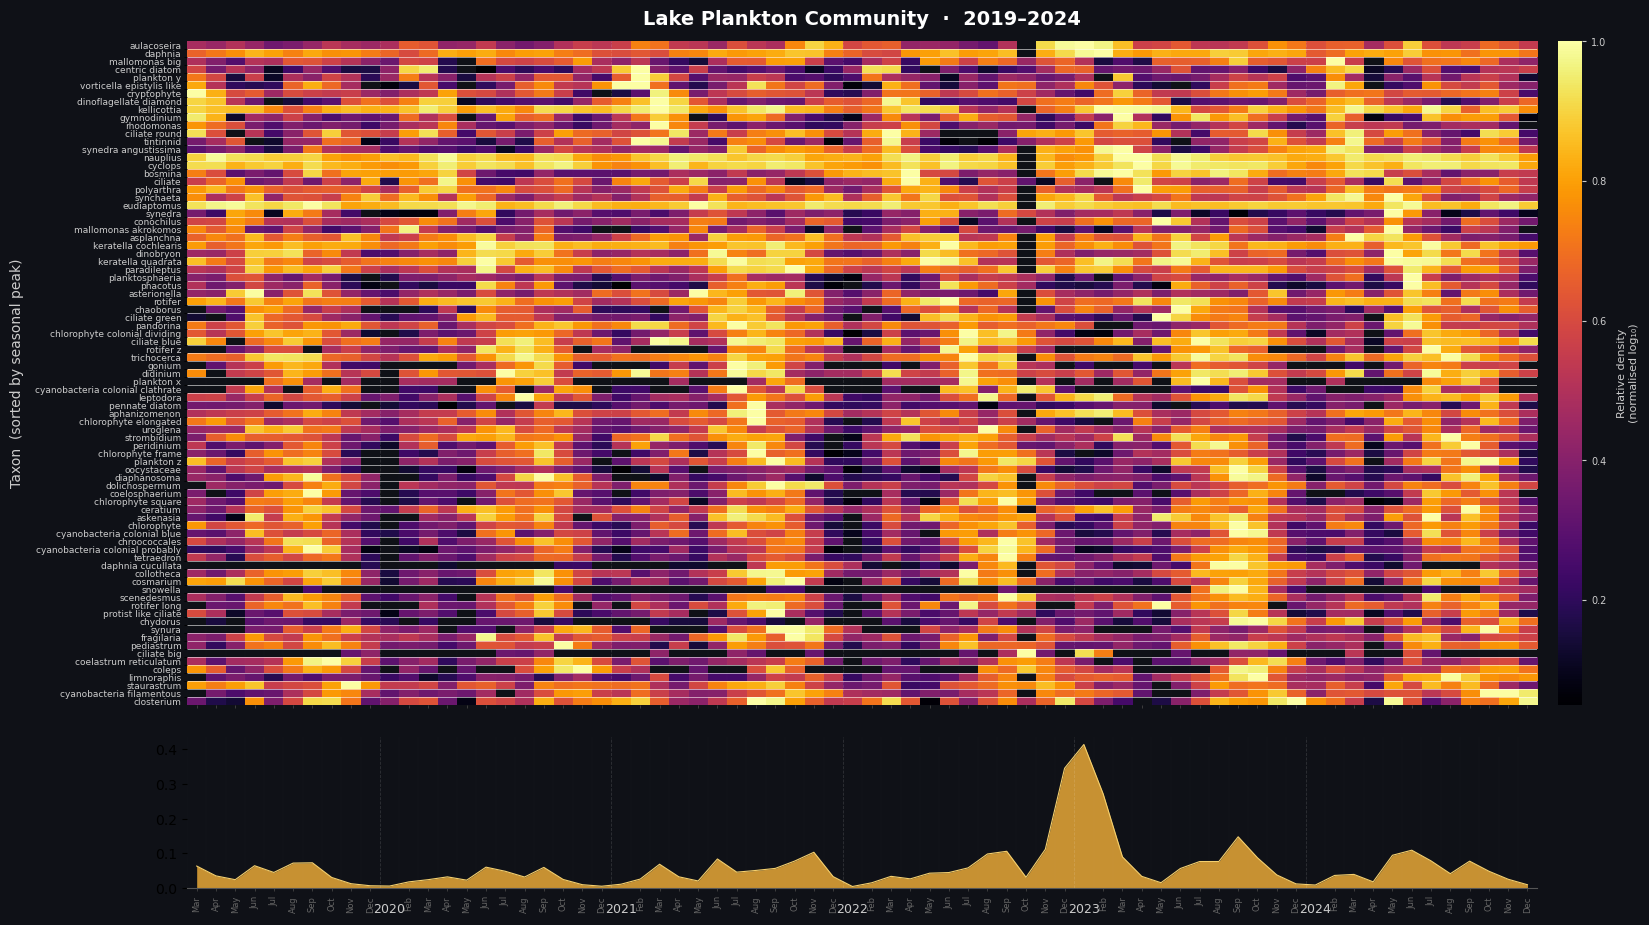

Figure saved → plankton_heatmap.png


In [6]:
# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0f1117')

# --- Grid layout: main heatmap (top) + total biomass strip (bottom) ----------
gs = fig.add_gridspec(2, 2,
                      height_ratios=[11, 2.5],
                      width_ratios=[1, 0.018],
                      hspace=0.08, wspace=0.03)

ax_heat  = fig.add_subplot(gs[0, 0])
ax_cbar  = fig.add_subplot(gs[0, 1])
ax_total = fig.add_subplot(gs[1, 0])

for ax in [ax_heat, ax_cbar, ax_total]:
    ax.set_facecolor('#0f1117')

# ── Heatmap ───────────────────────────────────────────────────────────────────
cmap = plt.get_cmap('inferno')
cmap.set_under('#0f1117')          # zero-density cells blend with background

im = ax_heat.imshow(
    mat,
    aspect='auto',
    origin='upper',
    cmap=cmap,
    vmin=0.05,                      # mask the near-zero background
    vmax=1.0,
    interpolation='nearest'
)

# ── Y-axis: species labels ────────────────────────────────────────────────────
n_taxa = len(sorted_taxa)
ax_heat.set_yticks(range(n_taxa))
ax_heat.set_yticklabels(
    [t.replace('_', ' ') for t in sorted_taxa],
    fontsize=6.5, color='#cccccc'
)
ax_heat.tick_params(axis='y', length=0, pad=4)

dates = df_monthly.index
n_months = len(dates)
 
jan_idx    = [i for i, d in enumerate(dates) if d.month == 1]
jan_labels = [str(dates[i].year) for i in jan_idx]
mon_idx    = [i for i, d in enumerate(dates) if d.month != 1]
mon_labels = [dates[i].strftime('%b') for i in mon_idx]
 
ax_heat.set_xticks(jan_idx)
ax_heat.set_xticklabels(jan_labels, color='#cccccc', fontsize=9)
ax_heat.set_xticks(mon_idx, minor=True)
ax_heat.tick_params(axis='x', which='major', length=0, labeltop=False, labelbottom=False)
ax_heat.tick_params(axis='x', which='minor', length=2, color='#444444', labelbottom=False)
 
for xi in jan_idx:
    ax_heat.axvline(xi - 0.5, color='#ffffff22', linewidth=0.6, linestyle='--')
for xi in mon_idx:
    ax_heat.axvline(xi - 0.5, color='#ffffff08', linewidth=0.3)

# Subtle horizontal grid between species
ax_heat.set_yticks([y - 0.5 for y in range(1, n_taxa)], minor=True)
ax_heat.grid(which='minor', axis='y', color='#ffffff08', linewidth=0.4)

ax_heat.set_ylabel('Taxon  (sorted by seasonal peak)', color='#cccccc', fontsize=10, labelpad=8)
ax_heat.set_title(
    'Lake Plankton Community  ·  2019–2024',
    color='white', fontsize=14, fontweight='bold', pad=12
)
for spine in ax_heat.spines.values():
    spine.set_visible(False)

# ── Colour bar ────────────────────────────────────────────────────────────────
cb = fig.colorbar(im, cax=ax_cbar)
cb.set_label('Relative density\n(normalised log₁₀)',
             color='#cccccc', fontsize=8, labelpad=8)
cb.ax.yaxis.set_tick_params(color='#cccccc', labelsize=7, length=3)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
cb.outline.set_visible(False)

# ── Bottom strip: total community density ─────────────────────────────────────
total = df_monthly[sorted_taxa].sum(axis=1)           # raw monthly total

ax_total.fill_between(
    range(n_months), total.values,
    color='#e8a838', alpha=0.85, linewidth=0
)
ax_total.plot(range(n_months), total.values,
              color='#f5d06e', linewidth=0.8)

ax_total.set_xlim(-0.5, n_months - 0.5)
ax_total.set_ylim(0)
ax_total.set_xticks(jan_idx)
ax_total.set_xticklabels(jan_labels, color='#cccccc', fontsize=9)
ax_total.set_xticks(mon_idx, minor=True)
ax_total.set_xticklabels(mon_labels, minor=True, color='#666666', fontsize=6, rotation=90)
ax_total.tick_params(axis='x', which='major', length=0, pad=10)
ax_total.tick_params(axis='x', which='minor', length=2, color='#444444')

for xi in jan_idx:
    ax_total.axvline(xi - 0.5, color='#ffffff22', linewidth=0.6, linestyle='--')
for xi in mon_idx:
    ax_total.axvline(xi - 0.5, color='#ffffff08', linewidth=0.3)

for spine in ax_total.spines.values():
    spine.set_visible(False)
ax_total.spines['bottom'].set_visible(True)
ax_total.spines['bottom'].set_color('#555555')

# ── Save & show ───────────────────────────────────────────────────────────────
plt.savefig('plankton_heatmap.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Figure saved → plankton_heatmap.png')


Period: 2019-07-22  →  2019-08-06
Spike  : mean total density = 0.04762  |  max = 0.20580
Baseline: mean total density = 0.05932

Top 15 taxa by combined score (excess × fold change):
                               Excess density  % of excess  Fold change  Combined score
dinobryon                            0.019244         78.5         4.10    7.896352e-02
uroglena                             0.003040         12.4         3.59    1.090950e-02
chlorophyte_colonial_dividing        0.002052          8.4         1.62    3.331180e-03
trichocerca                          0.000062          0.3         2.88    1.769600e-04
chlorophyte_frame                    0.000044          0.2         1.55    6.828000e-05
diaphanosoma                         0.000031          0.1         2.07    6.437000e-05
paradileptus                         0.000027          0.1         1.45    3.969000e-05
chlorophyte_square                   0.000013          0.1         1.03    1.293000e-05
rotifer_long           

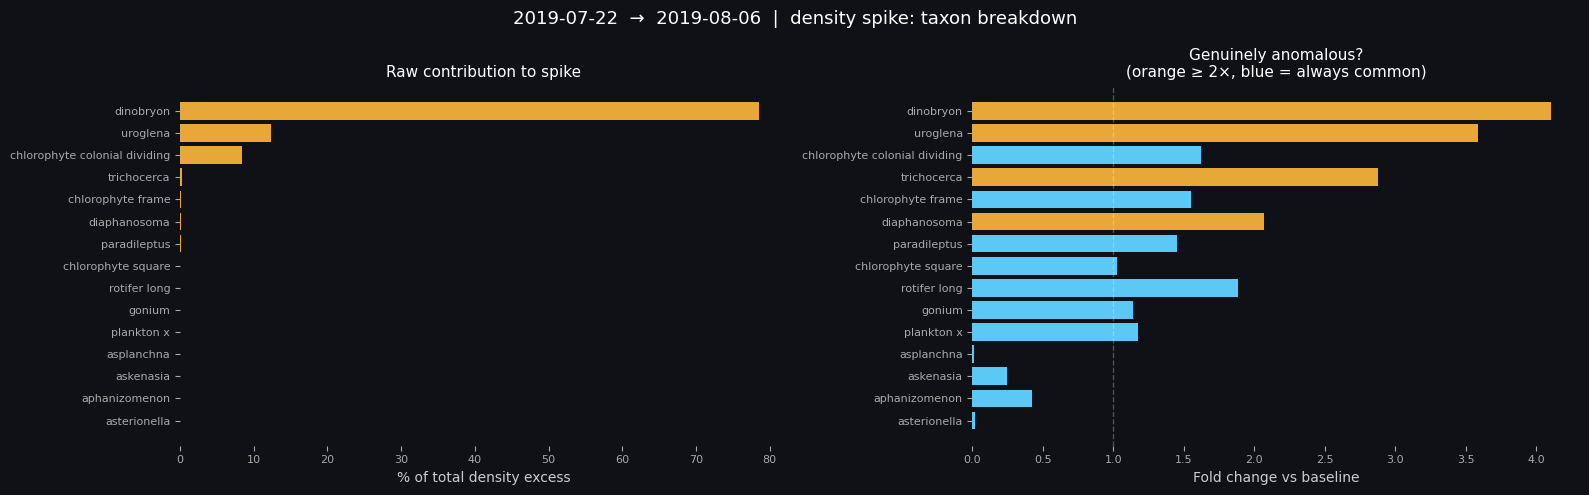


Period: 2022-10-01  →  2022-10-31
Spike  : mean total density = 0.03119  |  max = 0.09508
Baseline: mean total density = 0.05965

Top 15 taxa by combined score (excess × fold change):
                                  Excess density  % of excess  Fold change  Combined score
cyanobacteria_colonial_probably         0.004464         43.2         4.14        0.018475
chroococcales                           0.002145         20.8         4.53        0.009713
chlorophyte_square                      0.001024          9.9         3.36        0.003446
cyanobacteria_colonial_blue             0.000755          7.3         2.19        0.001654
scenedesmus                             0.000271          2.6         5.23        0.001417
cyanobacteria_colonial_clathrate        0.000143          1.4         9.44        0.001355
ciliate_big                             0.000019          0.2        56.81        0.001063
plankton_z                              0.000205          2.0         3.66        0.000

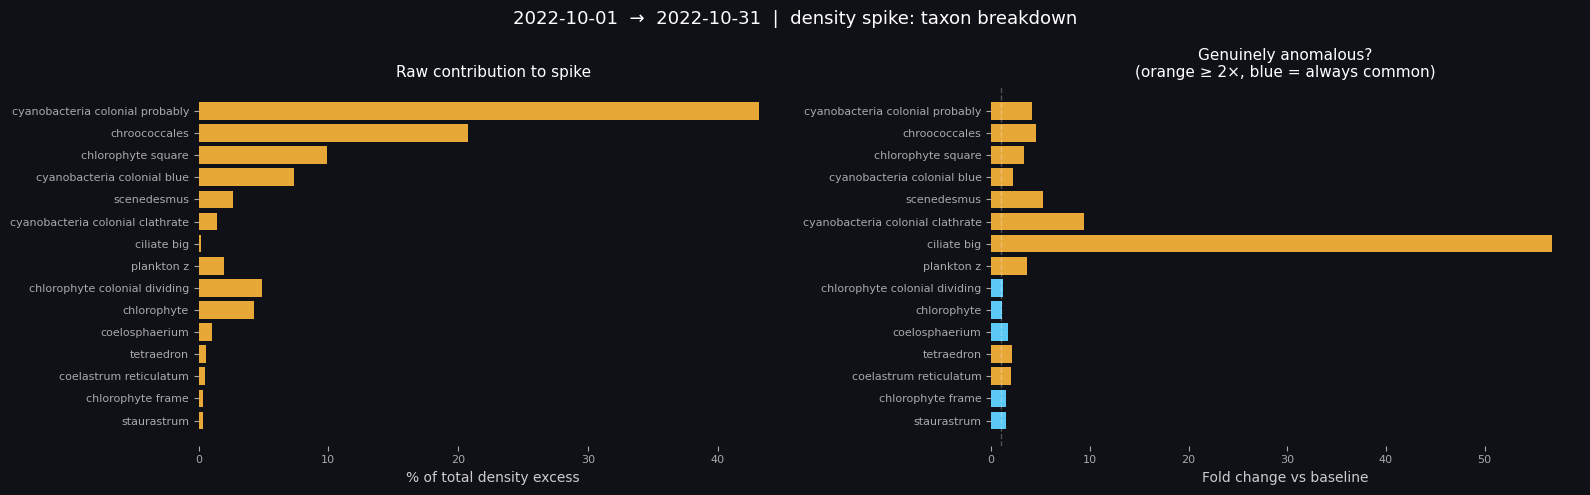


Period: 2022-12-10  →  2022-12-10
Spike  : mean total density = 0.00442  |  max = 0.00442
Baseline: mean total density = 0.05925

Top 15 taxa by combined score (excess × fold change):
                               Excess density  % of excess  Fold change  Combined score
closterium                           0.000324         90.3         2.55        0.000824
staurastrum                          0.000035          9.7         1.47        0.000051
aphanizomenon                        0.000000          0.0         0.00        0.000000
asterionella                         0.000000          0.0         0.00        0.000000
aulacoseira                          0.000000          0.0         0.00        0.000000
bosmina                              0.000000          0.0         0.00        0.000000
centric_diatom                       0.000000          0.0         0.96        0.000000
ceratium                             0.000000          0.0         0.00        0.000000
chaoborus              

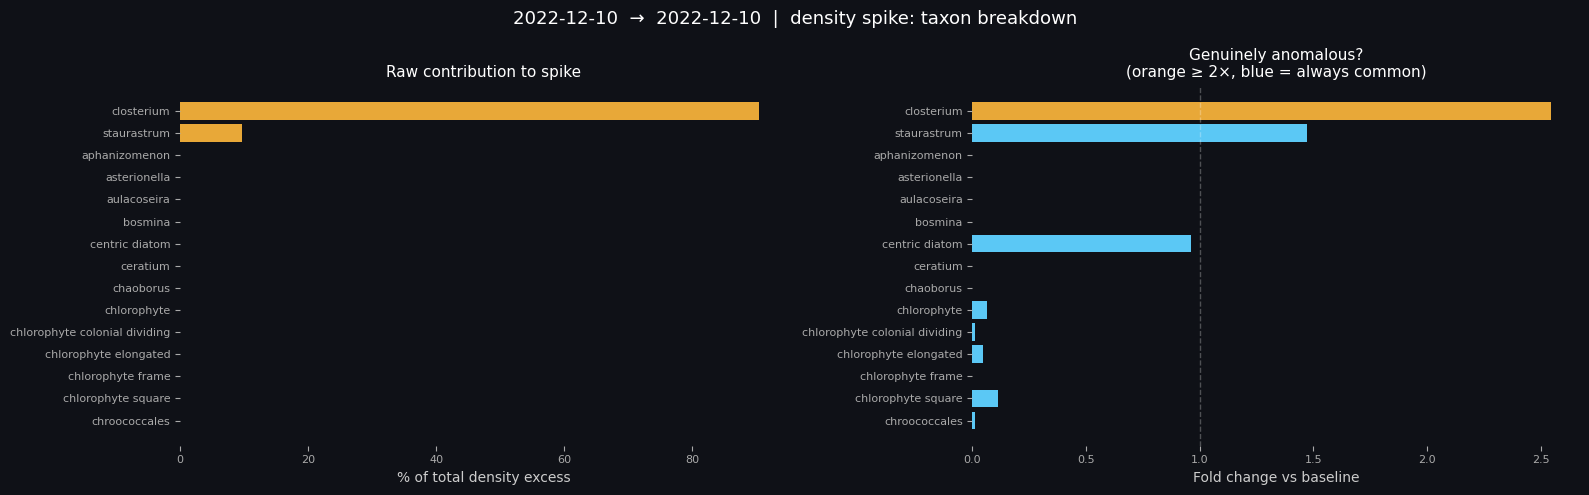

In [13]:
start_dates = ['2019-07-22', '2022-10-01', '2022-12-10']
end_dates   = ['2019-08-06', '2022-10-31', '2022-12-10']

for start, end in zip(start_dates, end_dates):
    spike_mask    = (df.index >= start) & (df.index <= end)   # ← use loop vars
    baseline_mask = ~spike_mask

    spike_mean    = df[spike_mask].mean()
    baseline_mean = df[baseline_mask].mean()

    spike_total = df[spike_mask].sum(axis=1)
    print(f"\n{'='*60}")
    print(f"Period: {start}  →  {end}")
    print(f"Spike  : mean total density = {spike_total.mean():.5f}  |  max = {spike_total.max():.5f}")
    print(f"Baseline: mean total density = {df[baseline_mask].sum(axis=1).mean():.5f}\n")

    excess       = (spike_mean - baseline_mean).clip(lower=0)
    total_excess = excess.sum()
    excess_pct   = 100 * excess / total_excess

    fold_change  = (spike_mean + 1e-12) / (baseline_mean + 1e-12)
    fold_change  = fold_change[baseline_mean > 1e-7]

    combined = (excess * fold_change.reindex(excess.index).fillna(1)).sort_values(ascending=False)
    top15    = combined.head(15).index

    print("Top 15 taxa by combined score (excess × fold change):")
    summary = pd.DataFrame({
        'Excess density': excess[top15].round(6),
        '% of excess':    excess_pct[top15].round(1),
        'Fold change':    fold_change.reindex(top15).round(2),
        'Combined score': combined[top15].round(8),
    })
    print(summary.to_string())

    top1_pct = excess_pct[top15[0]]
    print(f"\nTop taxon '{top15[0]}' accounts for {top1_pct:.1f}% of raw excess.")
    print("Single taxon driven." if top1_pct > 50 else "Cumulative effort across multiple taxa.")

    fc_top15 = fold_change.reindex(top15).fillna(1)
    colors   = ['#e8a838' if v >= 2 else '#5bc8f5' for v in fc_top15.values]
    labels   = [t.replace('_', ' ') for t in top15]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f1117')
    for ax in axes:
        ax.set_facecolor('#0f1117')

    axes[0].barh(labels[::-1], excess_pct[top15].values[::-1], color='#e8a838', edgecolor='none')
    axes[0].set_xlabel('% of total density excess', color='#cccccc')
    axes[0].set_title('Raw contribution to spike', color='white', fontsize=11)

    axes[1].barh(labels[::-1], fc_top15.values[::-1], color=colors[::-1], edgecolor='none')
    axes[1].axvline(1, color='#ffffff44', linewidth=1, linestyle='--')
    axes[1].set_xlabel('Fold change vs baseline', color='#cccccc')
    axes[1].set_title('Genuinely anomalous?\n(orange ≥ 2×, blue = always common)', color='white', fontsize=11)

    for ax in axes:
        ax.tick_params(colors='#aaaaaa', labelsize=8)
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.suptitle(f'{start}  →  {end}  |  density spike: taxon breakdown',
                 color='white', fontsize=13)
    plt.tight_layout()
    plt.show()


Period: 2019-07-22  →  2019-08-06
Period  : mean total density = 0.04762  |  max = 0.20580
Baseline: mean total density = 0.05932

Top 15 depleted taxa (deficit × fold depletion):
                                 Deficit density  % of deficit  Fold depletion  Combined score
aulacoseira                             0.018548          51.2         9650.48      178.992333
fragilaria                              0.001054           2.9         2025.05        2.134804
cyanobacteria_filamentous               0.000402           1.1          507.71        0.204176
asterionella                            0.000489           1.4           62.00        0.030318
centric_diatom                          0.001012           2.8           27.34        0.027655
oocystaceae                             0.002298           6.3            4.29        0.009860
asplanchna                              0.000101           0.3           93.10        0.009411
synchaeta                               0.000090           

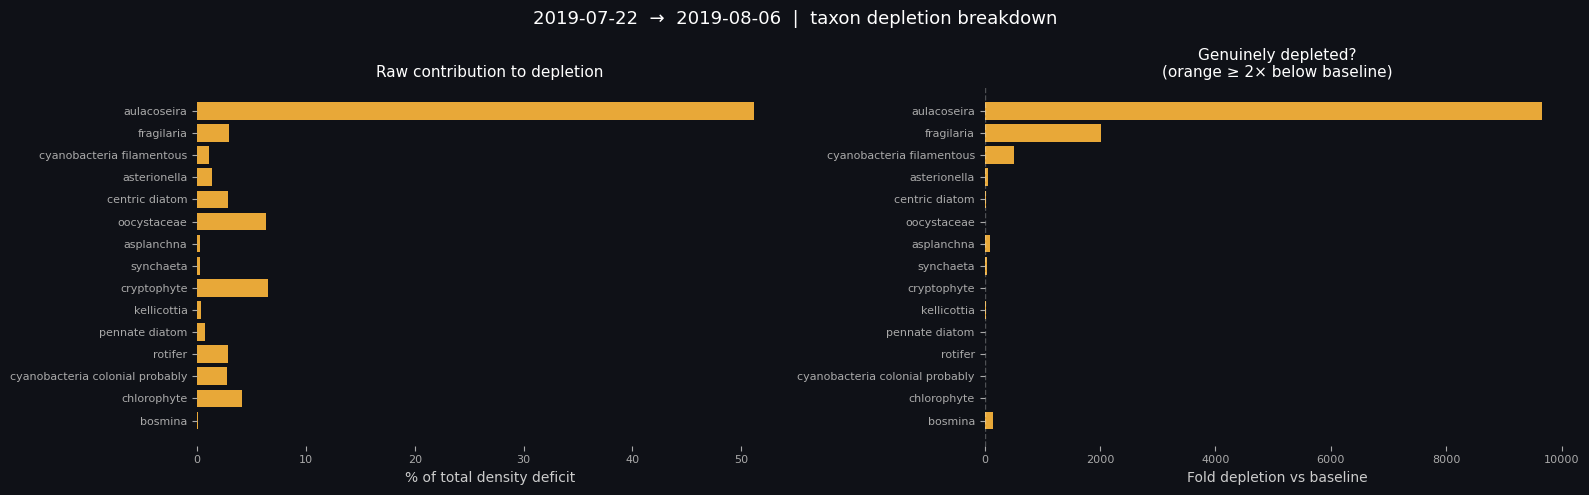


Period: 2022-10-01  →  2022-10-31
Period  : mean total density = 0.03119  |  max = 0.09508
Baseline: mean total density = 0.05965

Top 15 depleted taxa (deficit × fold depletion):
                        Deficit density  % of deficit  Fold depletion  Combined score
rotifer                        0.001549           4.0          869.67        1.347096
aulacoseira                    0.018686          48.2             NaN        0.018686
centric_diatom                 0.000915           2.4            7.50        0.006864
dinobryon                      0.006447          16.6             NaN        0.006447
rhodomonas                     0.001248           3.2            2.31        0.002886
cryptophyte                    0.001665           4.3            1.33        0.002216
uroglena                       0.001216           3.1             NaN        0.001216
fragilaria                     0.001062           2.7             NaN        0.001063
nauplius                       0.001039      

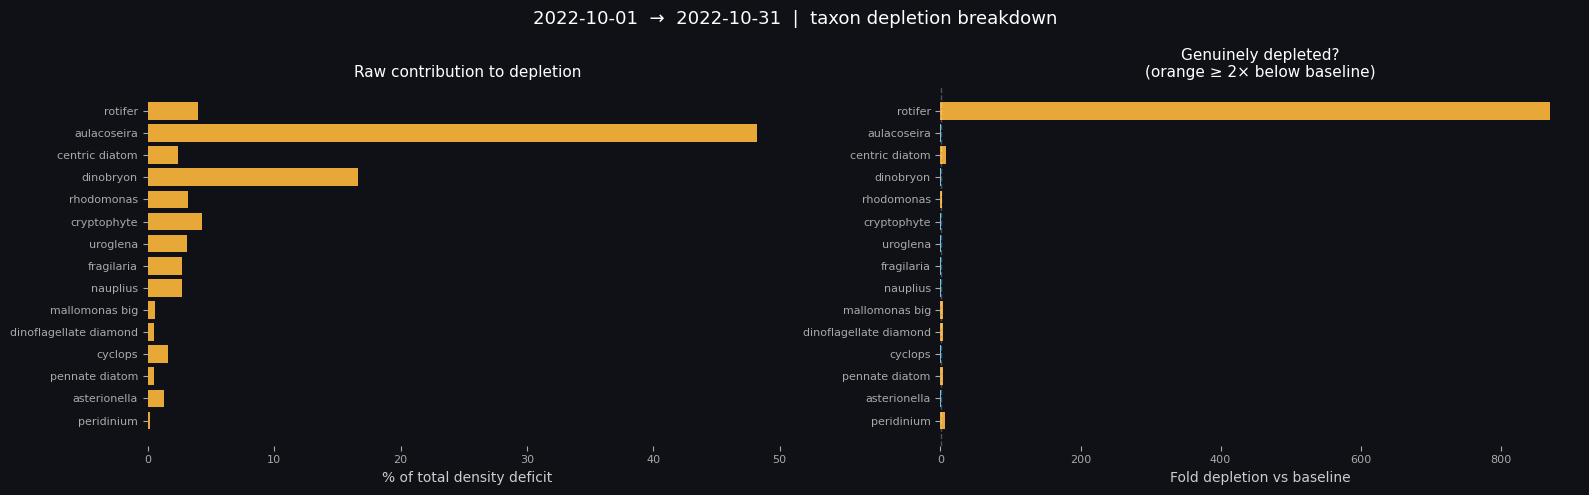


Period: 2022-12-10  →  2022-12-10
Period  : mean total density = 0.00442  |  max = 0.00442
Baseline: mean total density = 0.05925

Top 15 depleted taxa (deficit × fold depletion):
                                 Deficit density  % of deficit  Fold depletion  Combined score
chlorophyte_colonial_dividing           0.003276           5.9           99.28        0.325251
oocystaceae                             0.002946           5.3           89.38        0.263317
chlorophyte                             0.003213           5.8           15.83        0.050859
chroococcales                           0.000632           1.1           76.83        0.048551
cryptophyte                             0.005609          10.2            6.30        0.035330
cyanobacteria_colonial_probably         0.001423           2.6           22.35        0.031799
aulacoseira                             0.018415          33.4             NaN        0.018415
cyanobacteria_colonial_blue             0.000587           

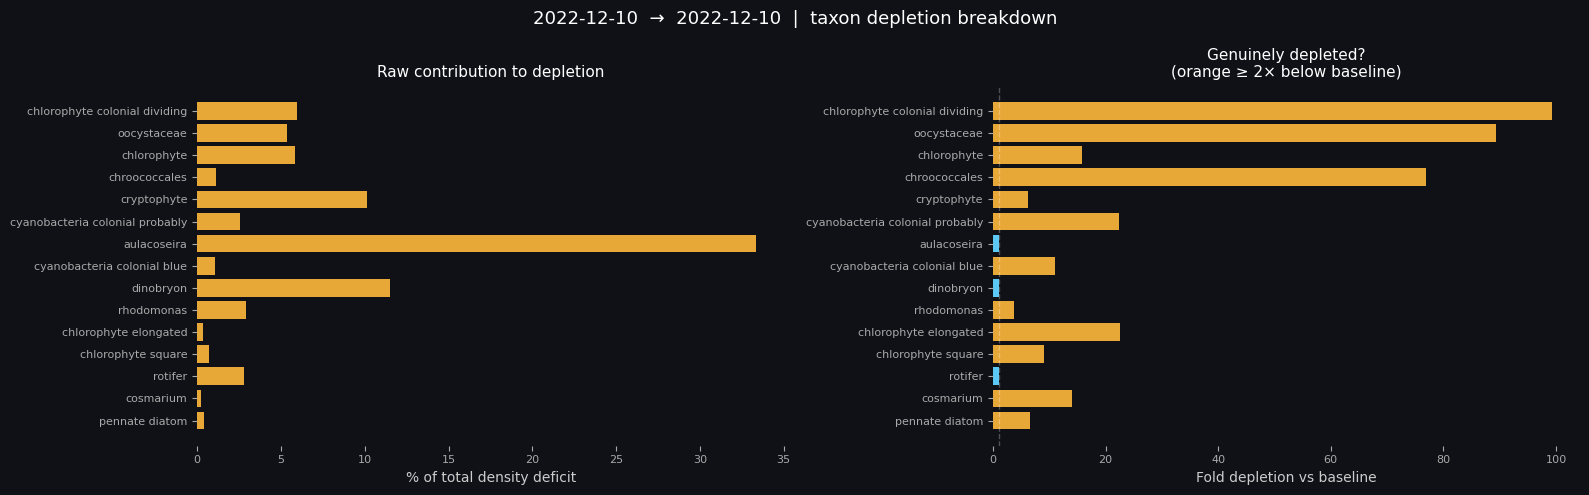

In [14]:
start_dates = ['2019-07-22', '2022-10-01', '2022-12-10']
end_dates   = ['2019-08-06', '2022-10-31', '2022-12-10']

for start, end in zip(start_dates, end_dates):
    spike_mask    = (df.index >= start) & (df.index <= end)
    baseline_mask = ~spike_mask

    spike_mean    = df[spike_mask].mean()
    baseline_mean = df[baseline_mask].mean()

    spike_total = df[spike_mask].sum(axis=1)
    print(f"\n{'='*60}")
    print(f"Period: {start}  →  {end}")
    print(f"Period  : mean total density = {spike_total.mean():.5f}  |  max = {spike_total.max():.5f}")
    print(f"Baseline: mean total density = {df[baseline_mask].sum(axis=1).mean():.5f}\n")

    # ── Absence: taxa below baseline during period ────────────────────────────
    excess       = (baseline_mean - spike_mean).clip(lower=0)
    total_excess = excess.sum()
    excess_pct   = 100 * excess / total_excess

    fold_change  = (baseline_mean + 1e-12) / (spike_mean + 1e-12)
    fold_change  = fold_change[spike_mean > 1e-7]   # exclude always-absent taxa

    combined = (excess * fold_change.reindex(excess.index).fillna(1)).sort_values(ascending=False)
    top15    = combined.head(15).index

    print("Top 15 depleted taxa (deficit × fold depletion):")
    summary = pd.DataFrame({
        'Deficit density': excess[top15].round(6),
        '% of deficit':   excess_pct[top15].round(1),
        'Fold depletion': fold_change.reindex(top15).round(2),
        'Combined score': combined[top15].round(8),
    })
    print(summary.to_string())

    top1_pct = excess_pct[top15[0]]
    print(f"\nTop depleted taxon '{top15[0]}' accounts for {top1_pct:.1f}% of total deficit.")
    print("Single taxon driven." if top1_pct > 50 else "Cumulative depletion across multiple taxa.")

    fc_top15 = fold_change.reindex(top15).fillna(1)
    colors   = ['#e8a838' if v >= 2 else '#5bc8f5' for v in fc_top15.values]
    labels   = [t.replace('_', ' ') for t in top15]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f1117')
    for ax in axes:
        ax.set_facecolor('#0f1117')

    axes[0].barh(labels[::-1], excess_pct[top15].values[::-1], color='#e8a838', edgecolor='none')
    axes[0].set_xlabel('% of total density deficit', color='#cccccc')
    axes[0].set_title('Raw contribution to depletion', color='white', fontsize=11)

    axes[1].barh(labels[::-1], fc_top15.values[::-1], color=colors[::-1], edgecolor='none')
    axes[1].axvline(1, color='#ffffff44', linewidth=1, linestyle='--')
    axes[1].set_xlabel('Fold depletion vs baseline', color='#cccccc')
    axes[1].set_title('Genuinely depleted?\n(orange ≥ 2× below baseline)', color='white', fontsize=11)

    for ax in axes:
        ax.tick_params(colors='#aaaaaa', labelsize=8)
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.suptitle(f'{start}  →  {end}  |  taxon depletion breakdown',
                 color='white', fontsize=13)
    plt.tight_layout()
    plt.show()

In [16]:
for start, end in zip(start_dates, end_dates):
      spike_mask    = (df.index >= start) & (df.index <= end)
      baseline_mask = ~spike_mask

      period_total   = df[spike_mask].sum(axis=1)        # total density per day in period
      baseline_total = df[baseline_mask].sum(axis=1)     # total density per day outside

      period_mean    = period_total.mean()
      baseline_mean_total = baseline_total.mean()
      depletion_abs  = baseline_mean_total - period_mean
      depletion_pct  = 100 * depletion_abs / (baseline_mean_total + 1e-12)

      print(f"Baseline mean total : {baseline_mean_total:.5f} µL⁻¹")
      print(f"Period mean total   : {period_mean:.5f} µL⁻¹")
      print(f"Absolute depletion  : {depletion_abs:+.5f} µL⁻¹")
      print(f"Relative depletion  : {depletion_pct:+.1f}%  "
            f"({'depleted' if depletion_pct > 0 else 'elevated'} vs baseline)")

Baseline mean total : 0.05932 µL⁻¹
Period mean total   : 0.04762 µL⁻¹
Absolute depletion  : +0.01170 µL⁻¹
Relative depletion  : +19.7%  (depleted vs baseline)
Baseline mean total : 0.05965 µL⁻¹
Period mean total   : 0.03119 µL⁻¹
Absolute depletion  : +0.02846 µL⁻¹
Relative depletion  : +47.7%  (depleted vs baseline)
Baseline mean total : 0.05925 µL⁻¹
Period mean total   : 0.00442 µL⁻¹
Absolute depletion  : +0.05483 µL⁻¹
Relative depletion  : +92.5%  (depleted vs baseline)
